In [1]:
import os
import librosa
import librosa.display
import soundfile as sf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# In this we are performing Resampling and Nomralization
print("Starting Resampling & Normalization...")

Starting Resampling & Normalization...


In [2]:
# Loading Manifest data
df = pd.read_csv("../DATA/processed/dataset_manifest.csv")

TARGET_SR = 22050
TARGET_DBFS = -20
# Convert dBFS to absolute RMS target
target_rms = 10 ** (TARGET_DBFS / 20)

In [10]:
!pip install resampy soxr


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
processed_manifest = []

for idx, row in df.iterrows():
    out_dir = os.path.join("../DATA/processed/resampled", row['class_label'])
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, row['filename'])
    
    # Load
    y_orig, sr_orig = librosa.load(row['filepath'], sr=None, mono=False)
    
    # Convert to Mono
    if y_orig.ndim > 1:
        y_mono = librosa.to_mono(y_orig)
    else:
        y_mono = y_orig
        
    # Resample
    if sr_orig != TARGET_SR:
        y_resampled = librosa.resample(y_mono, orig_sr=sr_orig, target_sr=TARGET_SR)
    else:
        y_resampled = y_mono
        
    # Normalize
    current_rms = np.sqrt(np.mean(y_resampled**2))
    if current_rms > 0:
        y_norm = y_resampled * (target_rms / current_rms)
    else:
        y_norm = y_resampled
        
    # Save Audio
    sf.write(out_path, y_norm, TARGET_SR)
    
    # Update manifest data
    processed_manifest.append({
        'filename': row['filename'],
        'class_label': row['class_label'],
        'filepath_original': row['filepath'],
        'filepath_processed': out_path,
        'sr_orig': sr_orig
    })

# Save new CSV
resampled_df = pd.DataFrame(processed_manifest)
resampled_df.to_csv("../DATA/processed/resampled_manifest.csv", index=False)
print(" Cell 1 Complete: All audio files processed and saved successfully!")

 Cell 1 Complete: All audio files processed and saved successfully!


Generating Before/After Spectrograms...


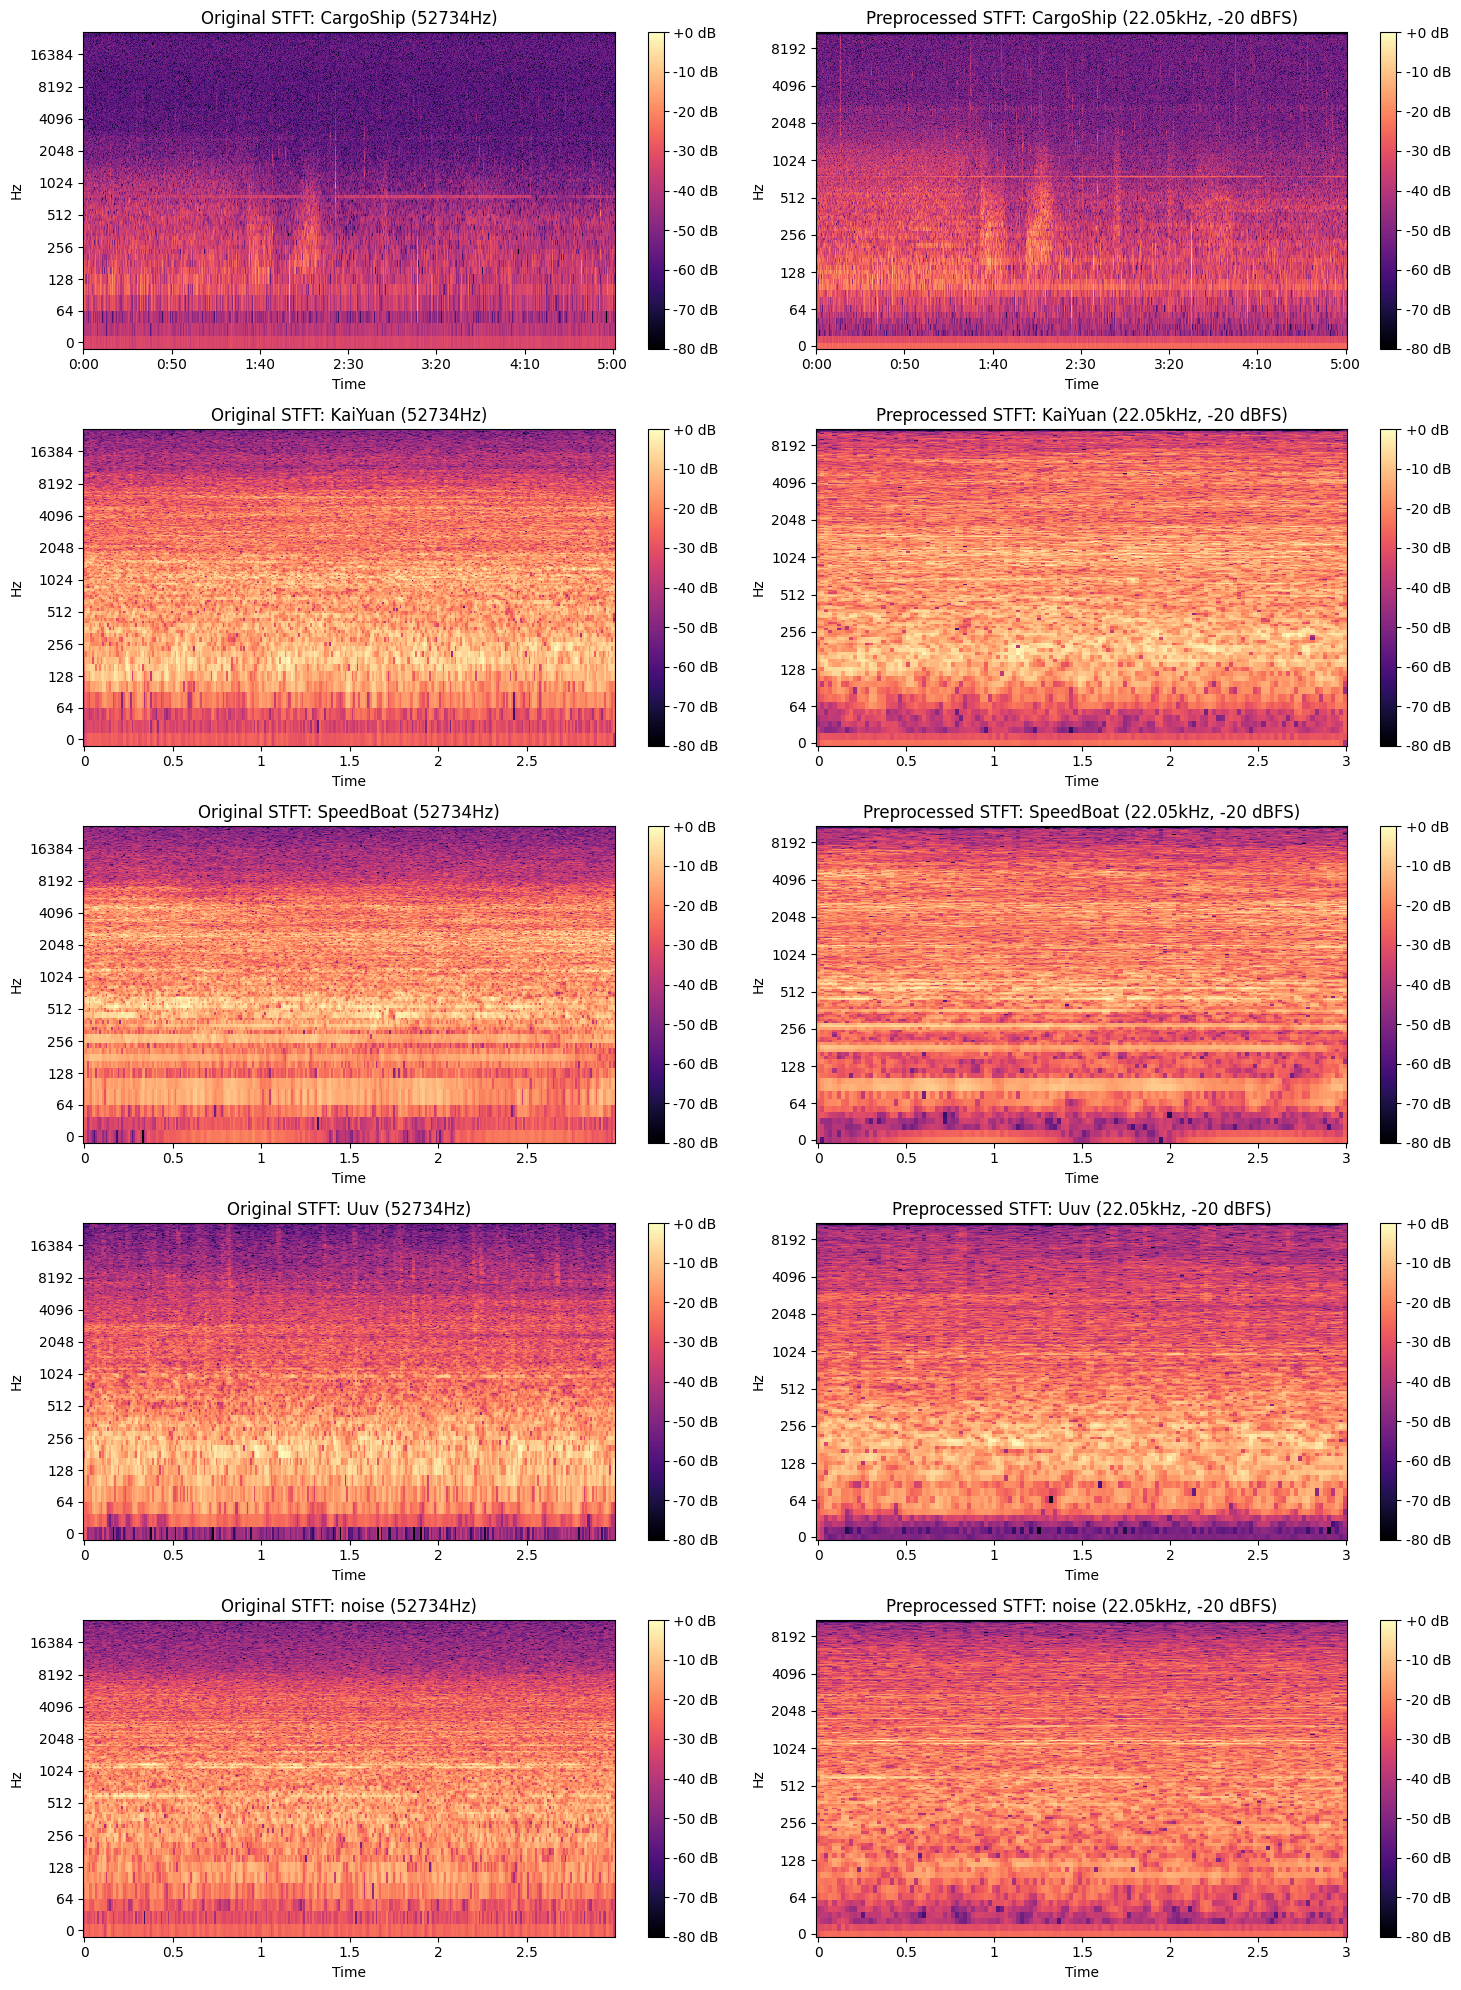

Spectrograms drawn successfully!


In [6]:
import librosa
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Generating Before/After Spectrograms...")

resampled_df = pd.read_csv("../DATA/processed/resampled_manifest.csv")
TARGET_SR = 22050
classes = resampled_df['class_label'].unique()

# Get exactly 1 file per class for plotting
plot_files = resampled_df.groupby('class_label').first().reset_index()

# Setup Plot 
fig, axes = plt.subplots(nrows=len(classes), ncols=2, figsize=(15, 4 * len(classes)))

for row_idx, row in plot_files.iterrows():
    # Load Original Audio
    y_orig, sr_orig = librosa.load(row['filepath_original'], sr=None, mono=True)
    # Load Processed Audio
    y_proc, sr_proc = librosa.load(row['filepath_processed'], sr=TARGET_SR, mono=True)
    
    # Draw Original STFT
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
    ax_orig = axes[row_idx, 0]
    img_orig = librosa.display.specshow(D_orig, sr=row['sr_orig'], x_axis='time', y_axis='log', ax=ax_orig)
    ax_orig.set_title(f"Original STFT: {row['class_label']} ({row['sr_orig']}Hz)")
    fig.colorbar(img_orig, ax=ax_orig, format="%+2.0f dB")
    
    # Draw Processed STFT
    D_proc = librosa.amplitude_to_db(np.abs(librosa.stft(y_proc)), ref=np.max)
    ax_proc = axes[row_idx, 1]
    img_proc = librosa.display.specshow(D_proc, sr=TARGET_SR, x_axis='time', y_axis='log', ax=ax_proc)
    ax_proc.set_title(f"Preprocessed STFT: {row['class_label']} (22.05kHz, -20 dBFS)")
    fig.colorbar(img_proc, ax=ax_proc, format="%+2.0f dB")

plt.tight_layout()
plt.show()
print("Spectrograms drawn successfully!")

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("Splitting data at RECORDING LEVEL (70/15/15)")

# Load the resampled manifest from Phase A
df = pd.read_csv("../DATA/processed/resampled_manifest.csv")

# Train (70%), Temp (30%)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['class_label'], random_state=42)
# Val (15%), Test (15%) -> Split the Temp 50/50
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['class_label'], random_state=42)

# Map splits back to the dataframe
split_map = {}
for f in train_df['filename']: split_map[f] = 'train'
for f in val_df['filename']: split_map[f] = 'val'
for f in test_df['filename']: split_map[f] = 'test'

df['split'] = df['filename'].map(split_map)

print(f"Data split done Train files: {len(train_df)}, Val files: {len(val_df)}, Test files: {len(test_df)}")

Splitting data at RECORDING LEVEL (70/15/15)
Data split done Train files: 98, Val files: 21, Test files: 21


In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import json

print("Segmenting audio into 3s chunks & saving splits.json")

TARGET_SR = 22050
SEG_LEN_S = 3
HOP_LEN_S = 1.5
SILENCE_THRESH_DBFS = -60
silence_thresh_rms = 10 ** (SILENCE_THRESH_DBFS / 20)

seg_samples = int(SEG_LEN_S * TARGET_SR)
hop_samples = int(HOP_LEN_S * TARGET_SR)

seg_dir = "../DATA/processed/segments"
os.makedirs(seg_dir, exist_ok=True)

segment_data = []
splits_dict = {'train': [], 'val': [], 'test': []}
discard_log = {cls: 0 for cls in df['class_label'].unique()}

for idx, row in df.iterrows():
    y, sr = librosa.load(row['filepath_processed'], sr=TARGET_SR, mono=True)
    
    # Sliding window for segments
    for i in range(0, len(y) - seg_samples + 1, hop_samples):
        segment = y[i:i + seg_samples]
        
        # Check silence (-60 dBFS threshold)
        rms = np.sqrt(np.mean(segment**2))
        if rms < silence_thresh_rms:
            discard_log[row['class_label']] += 1
            continue
            
        # Save valid segment
        seg_name = f"{row['class_label']}_{row['filename'].replace('.wav','')}_seg{i}.wav"
        seg_path = os.path.join(seg_dir, seg_name)
        sf.write(seg_path, segment, TARGET_SR)
        
        # Track data
        segment_data.append({
            'segment_filename': seg_name,
            'class_label': row['class_label'],
            'parent_file': row['filename'],
            'split': row['split'],
            'filepath': seg_path
        })
        splits_dict[row['split']].append(seg_name)

#  SAVE DELIVERABLES 
with open("../DATA/splits.json", "w") as f:
    json.dump(splits_dict, f)

seg_df = pd.DataFrame(segment_data)
seg_df.to_csv("../DATA/processed/segment_manifest.csv", index=False)

print("\n PART 3 COMPLETELY DONE")
print(" Discarded silent segments per class:", discard_log)
print("\n Final Segment Count Table (Class vs Split):")
print(pd.crosstab(seg_df['class_label'], seg_df['split']))

Segmenting audio into 3s chunks & saving splits.json

 PART 3 COMPLETELY DONE
 Discarded silent segments per class: {'CargoShip': 0, 'KaiYuan': 0, 'noise': 0, 'SpeedBoat': 0, 'Uuv': 0}

 Final Segment Count Table (Class vs Split):
split        test  train  val
class_label                  
CargoShip     597   2786  597
KaiYuan         5     21    4
SpeedBoat       4     21    5
Uuv             5     21    4
noise           4     21    5
